<a href="https://colab.research.google.com/github/KrishDalvi/Pandas/blob/main/Task%20-%2018.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ford_car_dataset.csv to ford_car_dataset.csv


In [ ]:
# Question 1

# Q1. Data Loading & Initial Analysis

print("--- Q1: Data Loading & Initial Analysis ---")

# Load the dataset
df = pd.read_csv("ford_car_dataset.csv")

# Clean column headers (strip leading/trailing whitespaces if any)
df.columns = df.columns.str.strip()

print("\nFirst 10 rows:")
print(df.head(10))

print("\nLast 5 rows:")
print(df.tail(5))

print(f"\nDataset Shape: {df.shape}")
print("\nData Types and Info:")
print(df.info())
print("=" * 95)

--- Q1: Data Loading & Initial Analysis ---

First 10 rows:
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

Last 5 rows:
        model  year  price transmission  mileage fuelType  tax   mpg

In [ ]:
# Question 2
# Q2. Missing & Duplicate Values

print("\n--- Q2: Missing & Duplicate Values ---")

# Check missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Check and remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicate_count}")

# Removing duplicates
df_cleaned = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df_cleaned.shape}")
print("=" * 60)


--- Q2: Missing & Duplicate Values ---
Missing values per column:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Total duplicate rows found: 154
Shape after removing duplicates: (17812, 9)


In [ ]:
# Question 3

# Q3. Statistical Summary

print("\n--- Q3: Statistical Summary ---")

# Statistical summary of numeric features
summary_stats = df_cleaned.describe()
print(summary_stats)

# Extract key statistics for price, mileage, and year
for col in ["price", "mileage", "year"]:

    print(f"\nKey Metrics for '{col}':")
    print(f"  Minimum: {df_cleaned[col].min()}")
    print(f"  Maximum: {df_cleaned[col].max()}")
    print(f"  Mean:    {df_cleaned[col].mean():.2f}")
    print(f"  Median:  {df_cleaned[col].median()}")
    print(f"  Standard Deviation: {df_cleaned[col].std():.2f}")

    print("=" * 60)


--- Q3: Statistical Summary ---
               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

Key Metrics for 'price':
  Minimum: 495
  Maxim


--- Q4: Generating Histograms ---


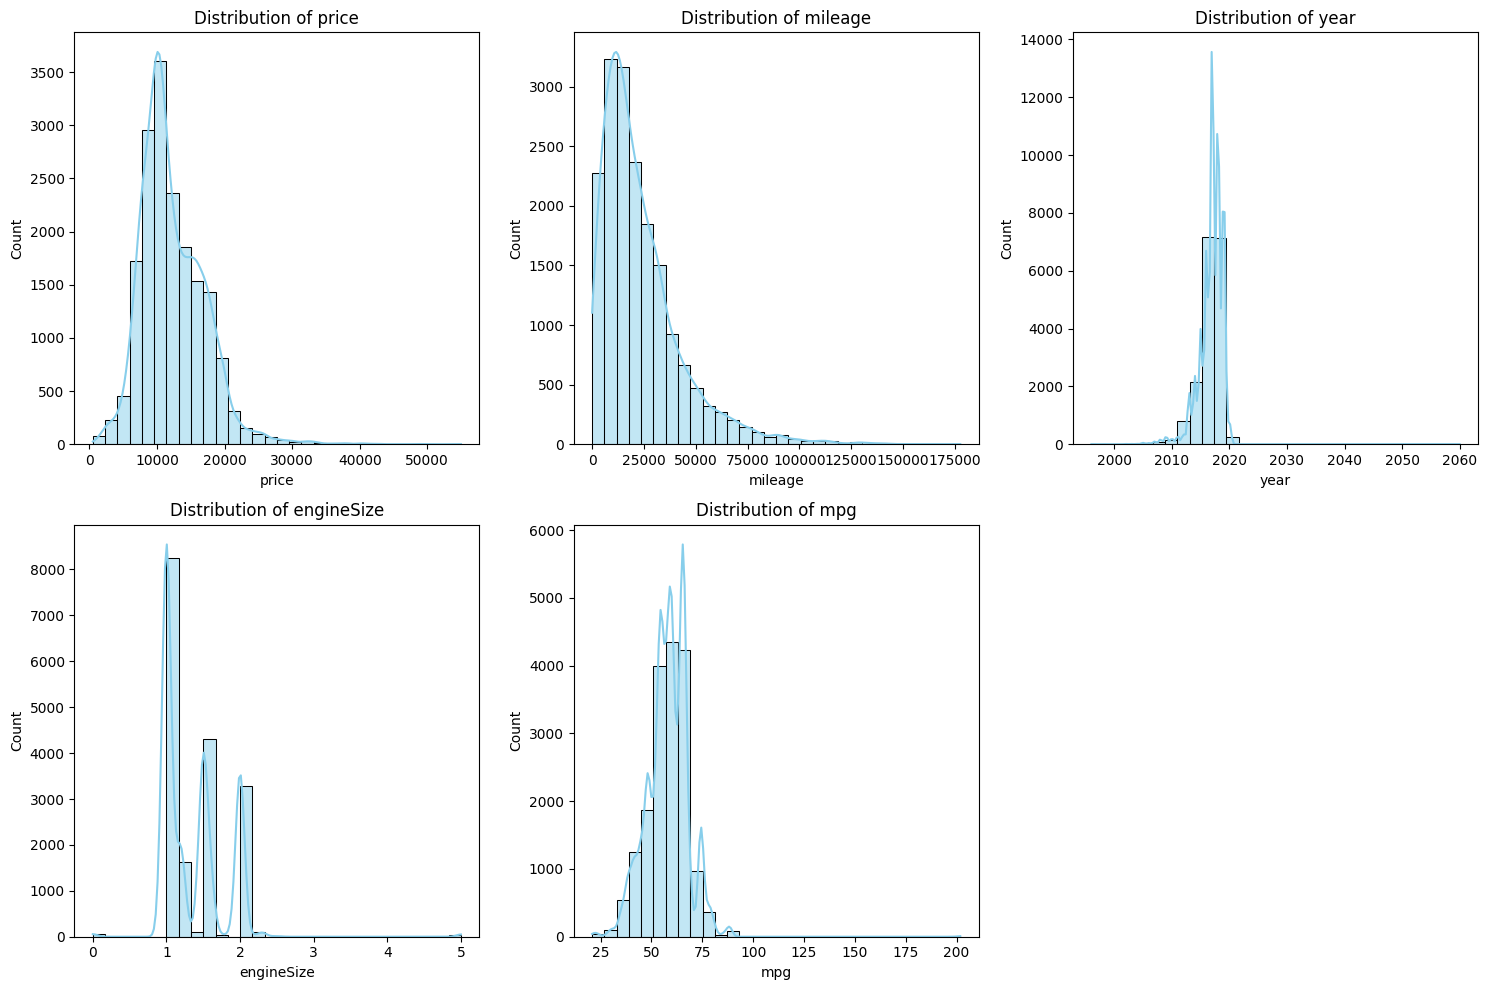

In [ ]:
# Question 4

# Q4. Histogram of Numeric Features

print("\n--- Q4: Generating Histograms ---")
numeric_cols = ["price", "mileage", "year", "engineSize", "mpg"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_cleaned[col], kde=True, bins=30, color="skyblue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


--- Q5: Generating Count Plots ---


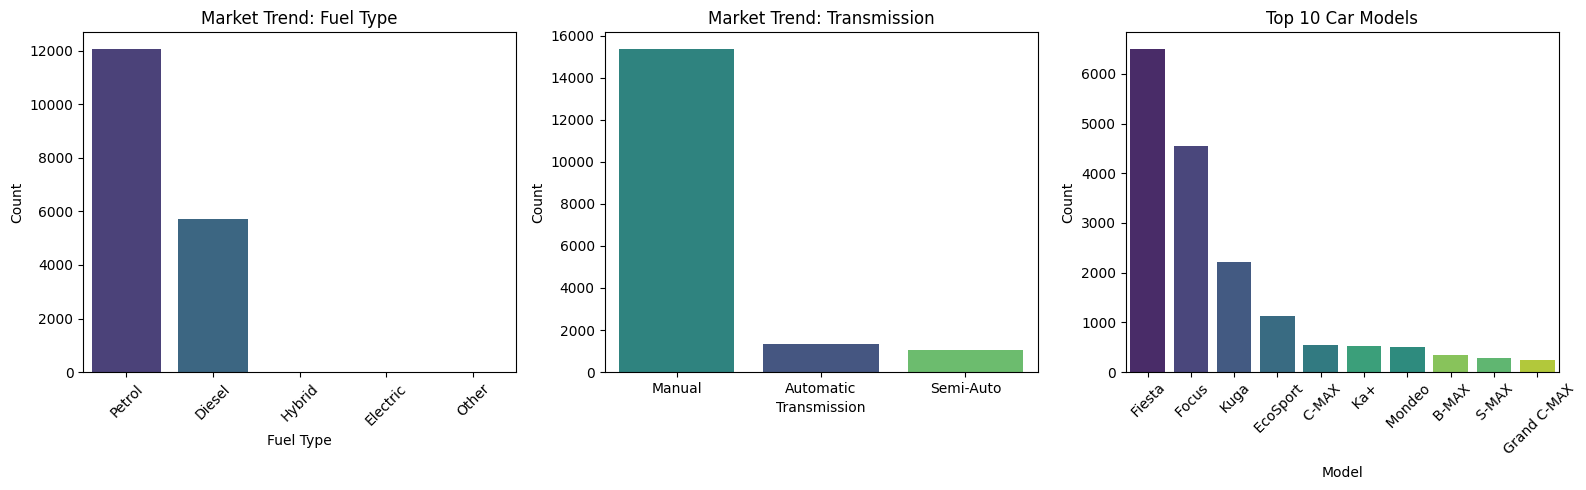

In [ ]:
# Question 5

print("\n--- Q5: Generating Count Plots ---")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 5))

# Fuel Type
plt.subplot(1, 3, 1)
sns.countplot(
    data=df_cleaned,
    x="fuelType",
    order=df_cleaned["fuelType"].value_counts().index,
    hue="fuelType",
    palette="viridis",
    legend=False
)
plt.title("Market Trend: Fuel Type")
plt.xticks(rotation=45)
plt.xlabel("Fuel Type")
plt.ylabel("Count")

# Transmission
plt.subplot(1, 3, 2)
sns.countplot(
    data=df_cleaned,
    x="transmission",
    order=df_cleaned["transmission"].value_counts().index,
    hue="transmission",
    palette="viridis",
    legend=False
)
plt.title("Market Trend: Transmission")
plt.xlabel("Transmission")
plt.ylabel("Count")

# Model (Top 10 models)
plt.subplot(1, 3, 3)
top_models = df_cleaned["model"].value_counts().head(10).index

sns.countplot(
    data=df_cleaned[df_cleaned["model"].isin(top_models)],
    x="model",
    order=top_models,
    hue="model",
    palette="viridis",
    legend=False
)
plt.title("Top 10 Car Models")
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


--- Q6: Generating Correlation Heatmap ---


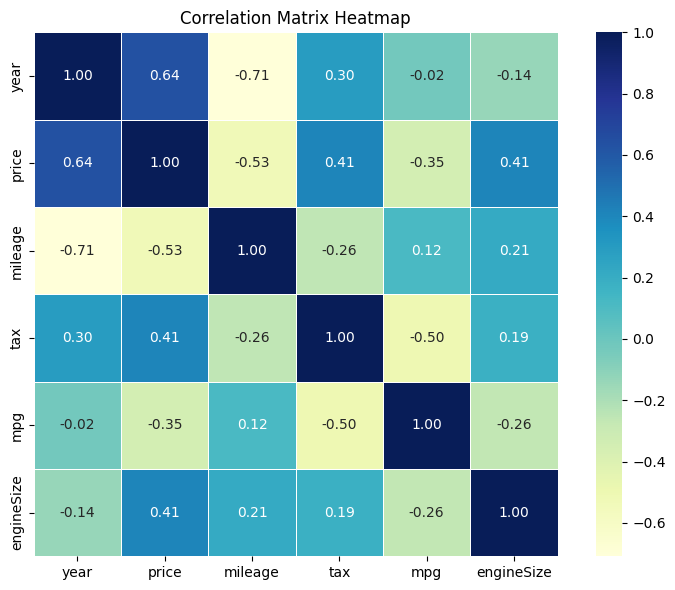

In [ ]:
# Question 6

print("\n--- Q6: Generating Correlation Heatmap ---")

# Filter numeric columns for correlation matrix
numeric_df = df_cleaned.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="YlGnBu",      # Changed color palette
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# Question 7

target = 'price'

# Independent Features
features = df.drop(columns=['price']).columns

print("\nDependent (Target) Feature:")
print(target)

print("\nIndependent (Features) Features:")
print(list(features))


Dependent (Target) Feature:
price

Independent (Features) Features:
['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']


In [ ]:
# Question 8


# Q8. Encoding Categorical Variables

print("\n--- Q8: Encoding Categorical Variables ---")
print("\n--- Before Transformation (Sample) ---")
print(df_cleaned[["transmission", "fuelType"]].head(3))

# Applying One-Hot Encoding via pandas
df_encoded = pd.get_dummies(
    df_cleaned, columns=["model", "transmission", "fuelType"], drop_first=True
)

print("\n--- After One-Hot Encoding Transformation (Sample) ---")

# Show columns corresponding to transmission and fuelType variants
encoded_sample_cols = [
    col
    for col in df_encoded.columns
    if "transmission" in col or "fuelType" in col
][:4]
print(df_encoded[encoded_sample_cols].head(3))
print("=" * 80)


--- Q8: Encoding Categorical Variables ---

--- Before Transformation (Sample) ---
  transmission fuelType
0    Automatic   Petrol
1       Manual   Petrol
2       Manual   Petrol

--- After One-Hot Encoding Transformation (Sample) ---
   transmission_Manual  transmission_Semi-Auto  fuelType_Electric  \
0                False                   False              False   
1                 True                   False              False   
2                 True                   False              False   

   fuelType_Hybrid  
0            False  
1            False  
2            False  


In [ ]:
# Question 9

print("\n--- Q9: Feature Scaling ---")

from sklearn.preprocessing import StandardScaler

# Independent numeric features (excluding the target 'price')
numeric_features = ["year", "mileage", "tax", "mpg", "engineSize"]

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the selected numeric features
df_encoded[numeric_features] = scaler.fit_transform(
    df_encoded[numeric_features]
)

# Display the first 5 rows of the scaled features
print("\nFirst 5 rows of fully preprocessed and scaled independent features:")
print(df_encoded[numeric_features].head())
print("=" * 70)


--- Q9: Feature Scaling ---

First 5 rows of fully preprocessed and scaled independent features:
       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


In [ ]:

# Q10. Mini Project - Complete Preprocessing Pipeline


# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

# ------------------------------------------
# Step 2: Load Dataset
# ------------------------------------------

print("Loading Dataset...")

# Change the path if your file is in another folder
df = pd.read_csv("ford.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ------------------------------------------
# Step 3: Data Cleaning
# ------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing values and duplicates
df_cleaned = df.dropna().drop_duplicates().copy()

print("\nShape after Cleaning:")
print(df_cleaned.shape)

# ------------------------------------------
# Step 4: Exploratory Data Analysis (EDA)
# ------------------------------------------

print("\nGenerating Histograms...")

numeric_cols = df_cleaned.select_dtypes(include=np.number).columns

df_cleaned[numeric_cols].hist(
    figsize=(15,8),
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

# ------------------------------------------
# Count Plots
# ------------------------------------------

print("\nGenerating Count Plots...")

plt.figure(figsize=(18,5))

# Fuel Type
if "fuelType" in df_cleaned.columns:
    plt.subplot(1,3,1)
    sns.countplot(
        data=df_cleaned,
        x="fuelType",
        order=df_cleaned["fuelType"].value_counts().index,
        hue="fuelType",
        palette="viridis",
        legend=False
    )
    plt.title("Fuel Type")
    plt.xticks(rotation=45)

# Transmission
if "transmission" in df_cleaned.columns:
    plt.subplot(1,3,2)
    sns.countplot(
        data=df_cleaned,
        x="transmission",
        order=df_cleaned["transmission"].value_counts().index,
        hue="transmission",
        palette="viridis",
        legend=False
    )
    plt.title("Transmission")

# Top 10 Models
if "model" in df_cleaned.columns:
    plt.subplot(1,3,3)

    top_models = df_cleaned["model"].value_counts().head(10).index

    sns.countplot(
        data=df_cleaned[df_cleaned["model"].isin(top_models)],
        x="model",
        order=top_models,
        hue="model",
        palette="viridis",
        legend=False
    )

    plt.title("Top 10 Models")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------

print("\nGenerating Correlation Heatmap...")

plt.figure(figsize=(8,6))

corr = df_cleaned.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------
# Step 5: Identify Input and Output Features
# ------------------------------------------

print("\nIdentifying Features...")

X = df_cleaned.drop("price", axis=1)
y = df_cleaned["price"]

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

# ------------------------------------------
# Step 6: Encode Categorical Variables
# ------------------------------------------

print("\nEncoding Categorical Variables...")

df_encoded = df_cleaned.copy()

label_encoder = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include="object").columns

for col in categorical_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

print(df_encoded.head())

# ------------------------------------------
# Step 7: Feature Scaling
# ------------------------------------------

print("\nScaling Numeric Features...")

numeric_features = ["year", "mileage", "mpg", "engineSize"]

# Add tax only if it exists
if "tax" in df_encoded.columns:
    numeric_features.append("tax")

scaler = StandardScaler()

df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

print("\nScaled Dataset (First 5 Rows):")
print(df_encoded.head())

print("\nMini Project Completed Successfully!")

Loading Dataset...


FileNotFoundError: [Errno 2] No such file or directory: 'ford.csv'